# Chapter 17: Capstone Project, Bean There Annual Review

*Data Analytics with Python and Jupyter Notebook*

The full 2025 review for Bean There, from twelve raw monthly till exports to a written report with recommendations. Run every cell in order with **Shift + Enter**, or use **Kernel > Restart & Run All**.

The owner's questions:

1. How much did we sell and earn in 2025, month by month?
2. Which stores make money after rent and staff, and when?
3. Which products drive revenue and profit, and how seasonal are they?
4. What does the Harbor kiosk pilot tell us about the permanent Harbor store?
5. How much does the weather drive Cold Brew sales?
6. Did the Riverside refit (August 2024) lift sales?

## 17.1 The brief

### Turning the request into questions

### Planning the notebook

## 17.2 Collect: survey the raw files

### Setting up

Every analysis notebook should start with one cell that does all the imports and settings, so nothing surprising happens further down:

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 80)
pd.set_option("display.max_columns", 12)
DATA = Path("../data")
FIGS = Path("../figures")
BLUE = "#4C72B0"

### Look before you load

With twelve files, the first job is to check that they all look the same. You can read just the first line of each file (its header) without loading any data:

In [2]:
files = sorted(DATA.glob("ch17_sales_2025_??.csv"))
for f in files:
    header = f.read_text().splitlines()[0]
    print(f.name, header)

ch17_sales_2025_01.csv date,store,product,category,quantity,unit_price,revenue
ch17_sales_2025_02.csv date,store,product,category,quantity,unit_price,revenue
ch17_sales_2025_03.csv date,store,product,category,quantity,unit_price,revenue
ch17_sales_2025_04.csv date,store,product,category,quantity,unit_price,revenue
ch17_sales_2025_05.csv date,store,product,category,quantity,unit_price,revenue
ch17_sales_2025_06.csv date,store,product,category,quantity,unit_price,revenue
ch17_sales_2025_07.csv Date,Location,Item,Qty,Unit Price,Total
ch17_sales_2025_08.csv Date,Location,Item,Qty,Unit Price,Total
ch17_sales_2025_09.csv Date,Location,Item,Qty,Unit Price,Total
ch17_sales_2025_10.csv Date,Location,Item,Qty,Unit Price,Total
ch17_sales_2025_11.csv Date,Location,Item,Qty,Unit Price,Total
ch17_sales_2025_12.csv Date,Location,Item,Qty,Unit Price,Total


Let's peek at the first three lines of one file from each system (January and August):

In [3]:
for f in [files[0], files[7]]:
    lines = f.read_text().splitlines()
    print("\n".join(lines[:3]), end="\n\n")

date,store,product,category,quantity,unit_price,revenue
2025-01-01,Downtown,Espresso,Coffee,24,3.0,72.0
2025-01-01,Downtown,Latte,Coffee,51,4.5,229.5

Date,Location,Item,Qty,Unit Price,Total
01/08/2025,Downtown,Espresso,33,$3.00,99.00
01/08/2025,Downtown,Latte,54,$4.50,243.00



### The reference tables

The three small tables load without surprises:

In [4]:
products = pd.read_csv(DATA / "ch17_products.csv")
stores = pd.read_csv(DATA / "ch17_stores.csv",
                     parse_dates=["opened", "closed"])
weather = pd.read_csv(DATA / "ch17_weather_2025.csv",
                      parse_dates=["date"])
products

,product,category,unit_price,unit_cost
0,Espresso,Coffee,3.00,0.55
1,Latte,Coffee,4.50,1.10
2,Cappuccino,Coffee,4.25,1.00
3,Cold Brew,Coffee,4.75,0.95
4,Croissant,Bakery,3.25,1.30
5,Blueberry Muffin,Bakery,2.95,1.10


Bakery items cost more to make relative to their price: a croissant sells for $3.25 and costs $1.30, while an espresso sells for $3.00 and costs only $0.55. Keep that in mind for the product analysis.

In [5]:
stores

,store,type,manager,opened,closed,seats,monthly_rent,monthly_staff,setup_cost
0,Downtown,Cafe,Priya Nair,2019-03-01,NaT,40,4500,10000,0
1,University,Cafe,Tom Okafor,2021-08-16,NaT,55,3200,8400,0
2,Riverside,Cafe,Lena Fischer,2022-05-06,NaT,24,2300,6600,0
3,Harbor Kiosk,Seasonal pilot,Sam Ortiz,2025-06-01,2025-09-30,0,1500,5400,4000


## 17.3 Clean: one reader for two formats

Chapter 6 showed how to combine many files with `pd.concat`, and Chapter 7 gave you a cleaning checklist. Here we need both, with a twist: the files do not share one format, so we write a **function** (Chapter 3) that reads any one file and returns it in a single standard layout. Then we apply it to every file.

In [6]:
NEW_NAMES = {"Date": "date", "Location": "store", "Item": "product",
             "Qty": "quantity", "Unit Price": "unit_price",
             "Total": "revenue"}


def read_export(path):
    """Read one monthly till export into the standard layout."""
    raw = pd.read_csv(path)
    if "Date" in raw.columns:                  # new till, from July
        raw = raw.rename(columns=NEW_NAMES)
        raw["date"] = pd.to_datetime(raw["date"], format="%d/%m/%Y")
        raw["unit_price"] = (raw["unit_price"]
                             .str.replace("$", "", regex=False)
                             .astype(float))
    else:                                      # old till, Jan to Jun
        raw["date"] = pd.to_datetime(raw["date"], format="%Y-%m-%d")
        raw = raw.drop(columns="category")
    raw["source_file"] = path.name
    return raw


raw = pd.concat([read_export(f) for f in files], ignore_index=True)
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7303 entries, 0 to 7302
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         7303 non-null   datetime64[us]
 1   store        7303 non-null   str           
 2   product      7303 non-null   str           
 3   quantity     7294 non-null   float64       
 4   unit_price   7303 non-null   float64       
 5   revenue      7303 non-null   float64       
 6   source_file  7303 non-null   str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 399.5 KB


### Check 1: store names

Now work through the checklist, one problem at a time.

In [7]:
raw["store"].value_counts()

store
University      2190
Downtown        1825
Riverside       1824
Harbor Kiosk     732
Downtown         366
riverside        366
Name: count, dtype: int64

There appear to be two Downtowns and two Riversides. Someone's till settings in April and May added a trailing space to "Downtown " and lower-cased "riverside". `.str.strip()` removes stray spaces at either end and `.str.title()` capitalizes each word:

In [8]:
raw["store"] = raw["store"].str.strip().str.title()
raw["store"].value_counts()

store
Downtown        2191
University      2190
Riverside       2190
Harbor Kiosk     732
Name: count, dtype: int64

### Check 2: unexpected products

A product that is not on the price list is either a new menu item or a mistake. Compare against the products table with `.isin()`:

In [9]:
unknown = ~raw["product"].isin(products["product"])
raw[unknown]

,date,store,product,quantity,unit_price,revenue,source_file
4944,2025-08-04,Downtown,TEST ITEM,1.0,0.0,0.0,ch17_sales_2025_08.csv


### Check 3: duplicate rows

Each combination of date, store and product should appear exactly once. `duplicated(keep=False)` marks every copy of a repeated key, including the first:

In [10]:
raw = raw[~unknown]
keys = ["date", "store", "product"]
dupes = raw[raw.duplicated(subset=keys, keep=False)]
print(len(dupes), "rows involved")
dupes["date"].value_counts()

36 rows involved


date
2025-03-15    36
Name: count, dtype: int64

### Check 4: missing quantities

All 36 rows belong to a single day, 15 March: the export for that day was written into the March file twice (18 rows, each appearing twice). Because the copies are identical, keeping the first of each is safe. If the copies had *different* quantities, you would need to ask the owner which one is right instead of choosing silently.

In [11]:
raw = raw.drop_duplicates(subset=keys, keep="first")
missing_qty = raw[raw["quantity"].isna()]
missing_qty[["date", "store", "product", "quantity", "revenue"]]

,date,store,product,quantity,revenue
255,2025-01-15,Downtown,Cold Brew,NaN,61.75
388,2025-01-22,University,Croissant,NaN,68.25
651,2025-02-06,Downtown,Cold Brew,NaN,52.25
1730,2025-04-06,Downtown,Cappuccino,NaN,161.50
2273,2025-05-06,Downtown,Blueberry Muffin,NaN,70.80
3275,2025-06-23,University,Blueberry Muffin,NaN,70.80
4094,2025-07-27,Riverside,Cappuccino,NaN,76.50
4358,2025-08-07,Riverside,Cappuccino,NaN,85.00
5533,2025-09-25,Riverside,Espresso,NaN,54.00


Nine quantities are blank, spread across the year and across both tills. In Chapter 7 you learned that the right treatment for a missing value depends on *why* it is missing. Here we are lucky: the revenue is still there, and revenue is quantity × price, so we can recover each quantity exactly instead of guessing:

In [12]:
filled = (raw["revenue"] / raw["unit_price"]).round()
raw["quantity"] = raw["quantity"].fillna(filled).astype(int)
print("Missing quantities left:", raw["quantity"].isna().sum())

Missing quantities left: 0


### Check 5: do the numbers add up?

Two rules should hold on every row: the price should match the price list, and revenue should equal quantity × price. A **merge** (Chapter 8) puts the list price next to each row so we can compare:

In [13]:
check = raw.merge(products[["product", "unit_price"]], on="product",
                  suffixes=("", "_list"))
wrong_price = (check["unit_price"] != check["unit_price_list"]).sum()
expected = check["quantity"] * check["unit_price"]
wrong_rev = ((check["revenue"] - expected).abs() > 0.01).sum()
print("Prices that differ from the list:", wrong_price)
print("Revenue that is not quantity x price:", wrong_rev)

Prices that differ from the list: 0
Revenue that is not quantity x price: 0


### Check 6: is anything missing?

Missing *rows* are harder to spot than missing values, because there is nothing there to see. Count the days each store appears:

In [14]:
days_open = raw.groupby("store")["date"].agg(["min", "max", "nunique"])
days_open

,min,max,nunique
store,,,
Downtown,2025-01-01,2025-12-31,364
Harbor Kiosk,2025-06-01,2025-09-30,122
Riverside,2025-01-01,2025-12-31,364
University,2025-01-01,2025-12-31,364


2025 had 365 days, so every permanent cafe is missing one day. Find exactly which dates are absent by comparing against a full calendar:

In [15]:
all_days = pd.date_range("2025-01-01", "2025-12-31")
for store in ["Downtown", "University", "Riverside"]:
    seen = raw.loc[raw["store"] == store, "date"].unique()
    gaps = all_days.difference(seen)
    print(f"{store:<11}", ", ".join(gaps.strftime("%b %d")))

Downtown    Dec 25
University  Dec 25
Riverside   Dec 25


### Check 7: does it agree with the daily totals?

There is one more source we can check against. The daily revenue file you analyzed in Chapter 9, `ch09_daily_revenue.csv`, holds each cafe's takings per day for 2023 to 2025, as recorded by the finance side of the business. The till exports should add up to the same numbers:

In [16]:
history = pd.read_csv(DATA / "ch09_daily_revenue.csv",
                      parse_dates=["date"])
daily_2025 = history[history["date"].dt.year == 2025]
till = (raw.groupby(["date", "store"])["revenue"].sum()
           .reset_index())
both = till.merge(daily_2025, on=["date", "store"], how="outer",
                  suffixes=("_till", "_daily"), indicator=True)
print(both["_merge"].value_counts())
diff = (both["revenue_till"] - both["revenue_daily"]).abs()
print(f"Largest difference: ${diff.max():.2f}")

_merge
both          1092
left_only      122
right_only       0
Name: count, dtype: int64
Largest difference: $0.02


### The clean, enriched table

Finally, assemble the analysis table in one method chain (Chapter 8): add each product's category and unit cost from the products table, then compute cost, gross profit and month.

In [17]:
sales = (raw
         .drop(columns="source_file")
         .merge(products[["product", "category", "unit_cost"]],
                on="product", how="left", validate="many_to_one")
         .assign(cost=lambda d: d["quantity"] * d["unit_cost"],
                 gross_profit=lambda d: d["revenue"] - d["cost"],
                 month=lambda d: d["date"].dt.month)
         .sort_values(["date", "store", "product"])
         .reset_index(drop=True))
sales.to_csv(DATA / "ch17_clean_sales_2025.csv", index=False)
sales.shape

(7284, 11)

## 17.4 Explore: how did 2025 go?

With clean data we can finally answer the owner's first question. Start with the headline numbers:

In [18]:
revenue = sales["revenue"].sum()
gross = sales["gross_profit"].sum()
print(f"Revenue:      ${revenue:,.0f}")
print(f"Gross profit: ${gross:,.0f} ({gross / revenue:.1%})")
print(f"Units sold:   {sales['quantity'].sum():,}")

Revenue:      $716,692
Gross profit: $529,132 (73.8%)
Units sold:   184,784


The daily file from Chapter 9 also lets us put 2025 in context, because it goes back to 2023 for the three cafes:

In [19]:
years = history.pivot_table(index=history["date"].dt.year,
                            columns="store", values="revenue",
                            aggfunc="sum")
years["Total"] = years.sum(axis=1)
print(years.round(0))
print((years.pct_change() * 100).round(1).dropna())

store  Downtown  Riverside  University     Total
date                                            
2023   256379.0   148172.0    170737.0  575288.0
2024   277294.0   155093.0    183897.0  616284.0
2025   297749.0   172166.0    199869.0  669784.0
store  Downtown  Riverside  University  Total
date                                         
2024        8.2        4.7         7.7    7.1
2025        7.4       11.0         8.7    8.7


### Month by month

A pivot table (Chapter 8) lays out revenue with months down the side and stores across the top:

In [20]:
by_month = sales.pivot_table(index="month", columns="store",
                             values="revenue", aggfunc="sum")
by_month["Total"] = by_month.sum(axis=1)
by_month.round(0)

store,Downtown,Harbor Kiosk,Riverside,University,Total
month,,,,,
1,22239.0,NaN,13044.0,15201.0,50484.0
2,20987.0,NaN,12050.0,14759.0,47796.0
3,24300.0,NaN,13802.0,17012.0,55113.0
4,24299.0,NaN,13702.0,17435.0,55437.0
5,26246.0,NaN,14965.0,18579.0,59789.0
6,26207.0,9364.0,14981.0,18136.0,68688.0
7,26947.0,14300.0,15798.0,13967.0,71011.0
8,26777.0,14856.0,15869.0,13929.0,71430.0
9,25592.0,8388.0,14842.0,18452.0,67274.0


Two months stand out. February is the weakest, and July and August are the strongest. But remember Chapter 1's lesson: before explaining a pattern, check whether it is real. February has only 28 days, so a fairer measure is **revenue per trading day**. Group to one row per store and day, then average within each month:

In [21]:
daily = sales.groupby(["store", "date"])["revenue"].sum().reset_index()
per_day = daily.pivot_table(index=daily["date"].dt.month,
                            columns="store", values="revenue",
                            aggfunc="mean")
per_day.round(0)

store,Downtown,Harbor Kiosk,Riverside,University
date,,,,
1,717.0,NaN,421.0,490.0
2,750.0,NaN,430.0,527.0
3,784.0,NaN,445.0,549.0
4,810.0,NaN,457.0,581.0
5,847.0,NaN,483.0,599.0
6,874.0,312.0,499.0,605.0
7,869.0,461.0,510.0,451.0
8,864.0,479.0,512.0,449.0
9,853.0,280.0,495.0,615.0


A line chart (Chapter 11) shows all of this at once:

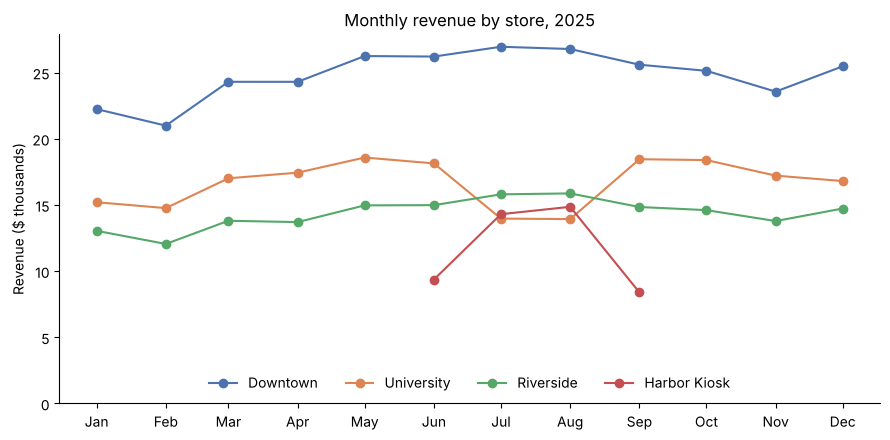

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
months = pd.date_range("2025-01-01", periods=12, freq="MS")
colors = {"Downtown": BLUE, "University": "#DD8452",
          "Riverside": "#55A868", "Harbor Kiosk": "#C44E52"}
for store in ["Downtown", "University", "Riverside", "Harbor Kiosk"]:
    ax.plot(months, by_month[store] / 1000, marker="o",
            color=colors[store], label=store)
ax.set_title("Monthly revenue by store, 2025")
ax.set_ylabel("Revenue ($ thousands)")
ax.set_ylim(0, None)
ax.set_xticks(months, months.strftime("%b"))
ax.legend(frameon=False, ncols=4, loc="lower center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / "ch17-monthly-revenue.png", dpi=150)
plt.show()

### How does 2025 compare with this year so far?

You already have the first three months of 2026: it is the running dataset from Chapter 1. Putting Q1 2025 next to Q1 2026 tells the owner whether the business is still growing:

In [23]:
q1_2025 = sales[sales["month"] <= 3]
q1_2026 = pd.read_csv(DATA / "bean_there_sales.csv")
cafes = ["Downtown", "University", "Riverside"]
q1 = pd.DataFrame({
    "Q1 2025": q1_2025.groupby("store")["revenue"].sum(),
    "Q1 2026": q1_2026.groupby("store")["revenue"].sum(),
}).loc[cafes]
q1.loc["Total"] = q1.sum()
q1["growth_%"] = (q1["Q1 2026"] / q1["Q1 2025"] - 1) * 100
q1.round(1)

,Q1 2025,Q1 2026,growth_%
store,,,
Downtown,67526.0,70205.3,4.0
University,46971.6,50570.4,7.7
Riverside,38895.3,40138.2,3.2
Total,153392.9,160913.9,4.9


### Products: what earns the money?

The owner asked about profit, not just sales, so we aggregate both. Named aggregation (Chapter 8) gives each output column a clear name:

In [24]:
prod = (sales.groupby("product")
        .agg(units=("quantity", "sum"),
             revenue=("revenue", "sum"),
             gross_profit=("gross_profit", "sum"))
        .sort_values("gross_profit", ascending=False))
prod["margin_%"] = prod["gross_profit"] / prod["revenue"] * 100
prod["share_%"] = prod["gross_profit"] / prod["gross_profit"].sum() * 100
prod.round(1)

,units,revenue,gross_profit,margin_%,share_%
product,,,,,
Latte,49100,220950.0,166940.0,75.6,31.5
Cappuccino,34138,145086.5,110948.5,76.5,21.0
Cold Brew,22693,107791.8,86233.4,80.0,16.3
Espresso,26942,80826.0,66007.9,81.7,12.5
Croissant,29668,96421.0,57852.6,60.0,10.9
Blueberry Muffin,22243,65616.8,41149.5,62.7,7.8


A sorted horizontal bar chart with value labels is the clearest way to show a ranking:

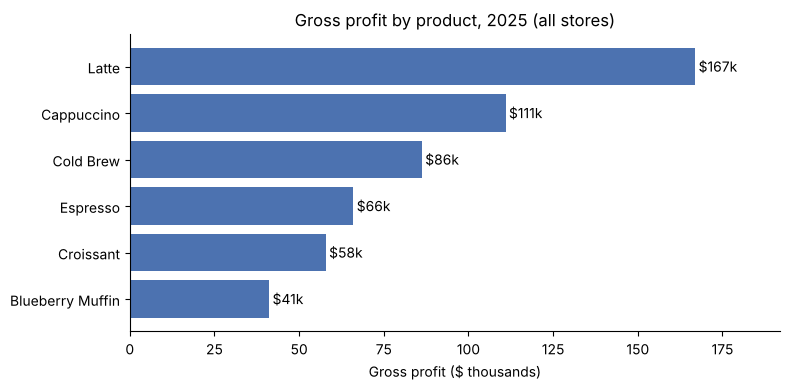

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
gp = prod["gross_profit"].sort_values() / 1000
ax.barh(gp.index, gp.values, color=BLUE)
for y, v in enumerate(gp.values):
    ax.text(v + 1, y, f"${v:,.0f}k", va="center")
ax.set_title("Gross profit by product, 2025 (all stores)")
ax.set_xlabel("Gross profit ($ thousands)")
ax.set_xlim(0, gp.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / "ch17-product-profit.png", dpi=150)
plt.show()

### Seasonality: a heatmap

Which products are seasonal? Comparing raw monthly totals would mix up three effects: month length, the kiosk coming and going, and genuine changes in what customers buy. So we use only the three year-round cafes, divide by the number of **store-days** traded in each month (one store open for one day counts as one), and then **index** each product to its own yearly average, so 100 means "a normal month for this product":

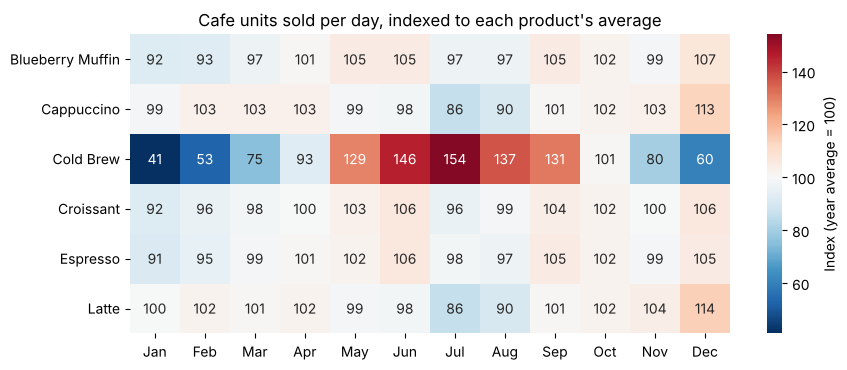

In [26]:
year_round = sales[sales["store"].isin(cafes)]
units = year_round.pivot_table(index="product", columns="month",
                               values="quantity", aggfunc="sum")
store_days = (year_round.drop_duplicates(["store", "date"])
              .groupby("month").size())
per_open_day = units / store_days
index = per_open_day.div(per_open_day.mean(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 3.8))
sns.heatmap(index.round(0), annot=True, fmt=".0f", cmap="RdBu_r",
            center=100, cbar_kws={"label": "Index (year average = 100)"},
            ax=ax)
ax.set_xticklabels(months.strftime("%b"))
ax.set_title("Cafe units sold per day, indexed to each product's average")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGS / "ch17-product-seasonality.png", dpi=150)
plt.show()

### Day of the week

Finally, a quick look at the weekly rhythm. `day_name()` gives the weekday's name and `.str[:3]` shortens it to three letters:

In [27]:
dow = daily.assign(weekday=daily["date"].dt.day_name().str[:3])
order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(dow.pivot_table(index="store", columns="weekday", values="revenue",
                 aggfunc="mean")
    .reindex(columns=order)
    .round(0))

weekday,Mon,Tue,Wed,Thu,Fri,Sat,Sun
store,,,,,,,
Downtown,762.0,764.0,776.0,768.0,751.0,957.0,947.0
Harbor Kiosk,317.0,305.0,330.0,338.0,310.0,559.0,531.0
Riverside,446.0,437.0,441.0,439.0,443.0,547.0,558.0
University,598.0,600.0,598.0,609.0,599.0,421.0,419.0


## 17.5 Profit: which stores make money, and when?

Gross profit ignores the two biggest costs of a coffee shop: rent and wages. To see what each store really contributes, merge in the stores table and subtract the monthly fixed costs. The result is usually called **contribution**: what a store contributes towards the owner's other overheads and profit.

In [28]:
monthly = (sales.groupby(["store", "month"])
           .agg(revenue=("revenue", "sum"),
                gross_profit=("gross_profit", "sum"))
           .reset_index()
           .merge(stores[["store", "monthly_rent", "monthly_staff"]],
                  on="store", how="left"))
monthly["fixed"] = monthly["monthly_rent"] + monthly["monthly_staff"]
monthly["contribution"] = monthly["gross_profit"] - monthly["fixed"]
monthly.head()

,store,month,revenue,gross_profit,monthly_rent,monthly_staff,fixed,contribution
0,Downtown,1,22238.95,16296.95,4500,10000,14500,1796.95
1,Downtown,2,20987.20,15426.65,4500,10000,14500,926.65
2,Downtown,3,24299.85,17891.95,4500,10000,14500,3391.95
3,Downtown,4,24299.15,17928.50,4500,10000,14500,3428.50
4,Downtown,5,26245.50,19412.35,4500,10000,14500,4912.35


In January, Downtown kept $16,297 after product costs and paid $14,500 in rent and staff, contributing $1,797. Now total it for the year, remembering to subtract the kiosk's one-off setup cost:

In [29]:
annual = monthly.groupby("store")[
    ["revenue", "gross_profit", "fixed", "contribution"]].sum()
annual = annual.join(stores.set_index("store")["setup_cost"])
annual["contribution"] -= annual["setup_cost"]
annual["contrib_%"] = annual["contribution"] / annual["revenue"] * 100
annual.sort_values("contribution", ascending=False).round(0)

,revenue,gross_profit,fixed,contribution,setup_cost,contrib_%
store,,,,,,
Downtown,297749.0,219723.0,174000,45723.0,0,15.0
Riverside,172166.0,126994.0,106800,20194.0,0,12.0
University,199869.0,147435.0,139200,8235.0,0,4.0
Harbor Kiosk,46908.0,34980.0,27600,3380.0,4000,7.0


`.join()` is a shortcut for merging on the index. To see each location's share of the total:

In [30]:
total_contrib = annual["contribution"].sum()
print(f"Total contribution: ${total_contrib:,.0f}")
(annual["contribution"] / total_contrib * 100).round(1)

Total contribution: $77,532


store
Downtown        59.0
Harbor Kiosk     4.4
Riverside       26.0
University      10.6
Name: contribution, dtype: float64

A monthly chart shows where the money is won and lost:

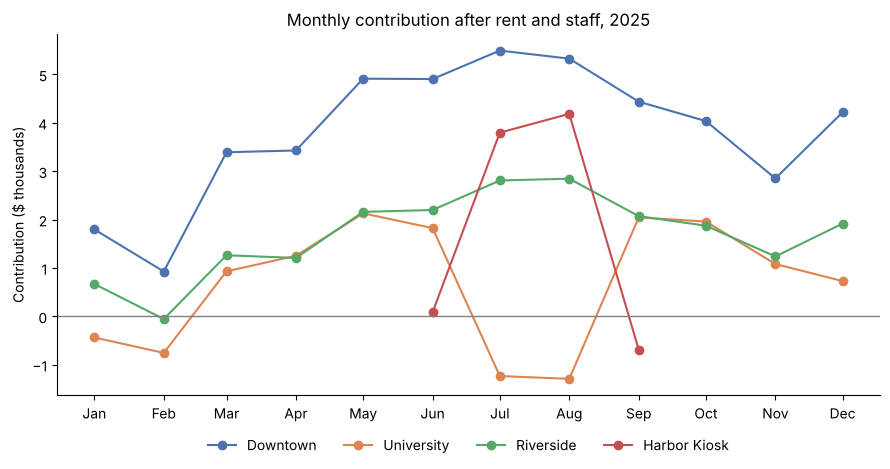

In [31]:
contrib = monthly.pivot_table(index="month", columns="store",
                              values="contribution")
fig, ax = plt.subplots(figsize=(9, 4.8))
for store in ["Downtown", "University", "Riverside", "Harbor Kiosk"]:
    ax.plot(months, contrib[store] / 1000, marker="o",
            color=colors[store], label=store)
ax.axhline(0, color="grey", linewidth=1)
ax.set_title("Monthly contribution after rent and staff, 2025")
ax.set_ylabel("Contribution ($ thousands)")
ax.set_xticks(months, months.strftime("%b"))
ax.legend(frameon=False, ncols=4, loc="upper center",
          bbox_to_anchor=(0.5, -0.08))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / "ch17-store-contribution.png", dpi=150)
plt.show()

### University's quiet months

Let's measure those dips:

In [32]:
uni = contrib["University"]
losing = uni[uni < 0]
print(losing.round(0))
print("Lost in those months:", round(losing.sum()))
print("Earned in the other months:", round(uni[uni >= 0].sum()))

month
1    -436.0
2    -755.0
7   -1234.0
8   -1291.0
Name: University, dtype: float64
Lost in those months: -3717
Earned in the other months: 11952


### Question 4: what does the pilot say about the new Harbor store?

University lost about $3,700 in four months, which cancels nearly a third of what it earned in the other eight. Its daily sales fall by about a quarter when students are away, but its rent and staff costs do not change. Rent is fixed, but staff hours are not: a rota sized to the academic calendar is the most direct lever the owner has. Exercise 5 puts a number on it.

In [33]:
kiosk = (monthly[monthly["store"] == "Harbor Kiosk"]
         .set_index("month")[["revenue", "gross_profit", "fixed",
                              "contribution"]])
kiosk.round(0)

,revenue,gross_profit,fixed,contribution
month,,,,
6,9364.0,6987.0,6900,87.0
7,14300.0,10697.0,6900,3797.0
8,14856.0,11085.0,6900,4185.0
9,8388.0,6211.0,6900,-689.0


A useful way to express this for a new store is a **break-even** figure: how much a day the site must take to cover its fixed costs. Gross profit is a fixed share of revenue (the margin), so break-even daily revenue is the monthly fixed cost divided by the margin, divided by the days in a month:

In [34]:
margin = kiosk["gross_profit"].sum() / kiosk["revenue"].sum()
fixed = kiosk["fixed"].iloc[0]
breakeven = fixed / margin / 30
print(f"Gross margin:       {margin:.1%}")
print(f"Break-even per day: ${breakeven:,.0f}")
per_day["Harbor Kiosk"].dropna().round(0)

Gross margin:       74.6%
Break-even per day: $308


date
6    312.0
7    461.0
8    479.0
9    280.0
Name: Harbor Kiosk, dtype: float64

## 17.6 Model lightly: one test and one forecast

### Did the Riverside refit lift sales?

The owner hopes so. The refit happened in August 2024, so the 2025 exports cannot answer this, but the Chapter 9 history file can. Chapter 14 taught the right tool: compare daily revenue in the four weeks before the closure (12 to 18 August 2024) with the four weeks after, and use a **t-test** to ask whether the difference is bigger than normal day-to-day noise.

In [35]:
from scipy import stats

river = (history[history["store"] == "Riverside"]
         .set_index("date")["revenue"])
before = river["2024-07-15":"2024-08-11"]
after = river["2024-08-19":"2024-09-15"]
print(f"Before: {len(before)} days, mean ${before.mean():,.0f}")
print(f"After:  {len(after)} days, mean ${after.mean():,.0f}")
result = stats.ttest_ind(after, before, equal_var=False)
print(f"Welch t = {result.statistic:.2f}, p = {result.pvalue:.3f}")

Before: 28 days, mean $458
After:  28 days, mean $454
Welch t = -0.24, p = 0.812


### How much does weather drive Cold Brew?

The heatmap suggested Cold Brew follows the seasons. Is that really temperature, or just "summer"? Merge each day's Cold Brew sales at the three cafes with that day's high temperature, then measure the **correlation** (Chapter 14):

In [36]:
cold = (sales[(sales["product"] == "Cold Brew")
              & (sales["store"].isin(cafes))]
        .groupby("date")["quantity"].sum()
        .rename("cold_brew")
        .reset_index()
        .merge(weather, on="date", how="left"))
cold[["cold_brew", "high_temp_f"]].corr().round(3)

,cold_brew,high_temp_f
cold_brew,1.000,0.951
high_temp_f,0.951,1.000


To turn the relationship into a planning tool, fit a **linear regression** with scikit-learn (Chapter 15). The time-ordered split is important. We train on January to September and test on October to December, because in real life you always forecast days you have not seen yet, and a random split would let the model peek at the future.

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

train = cold[cold["date"] < "2025-10-01"]
test = cold[cold["date"] >= "2025-10-01"]
model = LinearRegression()
model.fit(train[["high_temp_f"]], train["cold_brew"])
pred = model.predict(test[["high_temp_f"]])
print(f"Intercept: {model.intercept_:.1f}")
print(f"Slope:     {model.coef_[0]:.2f} cups per degree F")
mae = mean_absolute_error(test["cold_brew"], pred)
print(f"Test MAE (Oct to Dec): {mae:.1f} cups per day")
print(f"Test average:          {test['cold_brew'].mean():.1f} cups")

Intercept: -22.8
Slope:     1.28 cups per degree F
Test MAE (Oct to Dec): 4.7 cups per day
Test average:          44.3 cups


The owner does not want a slope; they want a rule of thumb for the morning order. A small table does that:

In [38]:
plan = pd.DataFrame({"high_temp_f": [40, 60, 80, 90]})
plan["cold_brew_forecast"] = model.predict(plan).round(0)
plan

,high_temp_f,cold_brew_forecast
0,40,28.0
1,60,54.0
2,80,79.0
3,90,92.0


Cold Brew is steeped 12 to 24 hours ahead, so a forecast from tomorrow's weather report is exactly what the staff need. A scatter plot with the fitted line shows how well the straight line fits:

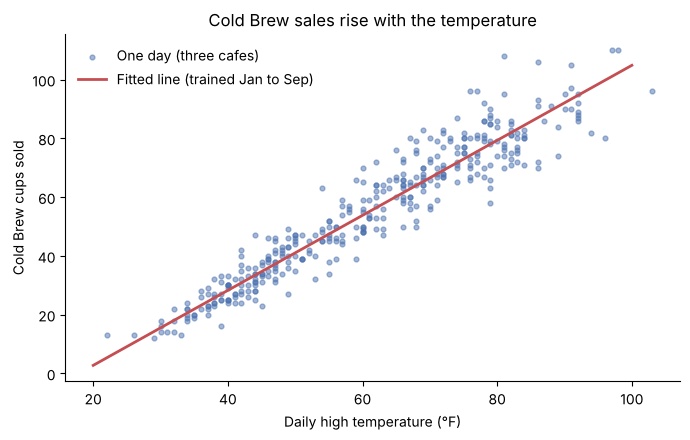

In [39]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(cold["high_temp_f"], cold["cold_brew"], s=12, alpha=0.5,
           color=BLUE, label="One day (three cafes)")
xs = pd.DataFrame({"high_temp_f": np.linspace(20, 100, 50)})
ax.plot(xs["high_temp_f"], model.predict(xs), color="#C44E52",
        linewidth=2, label="Fitted line (trained Jan to Sep)")
ax.set_title("Cold Brew sales rise with the temperature")
ax.set_xlabel("Daily high temperature (°F)")
ax.set_ylabel("Cold Brew cups sold")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / "ch17-cold-brew-temperature.png", dpi=150)
plt.show()

## 17.7 Communicate: the annual review

### One figure to open the report

A single summary figure with four small panels gives the whole year at a glance. Each panel reuses a variable we have already computed, so the figure cannot disagree with the tables:

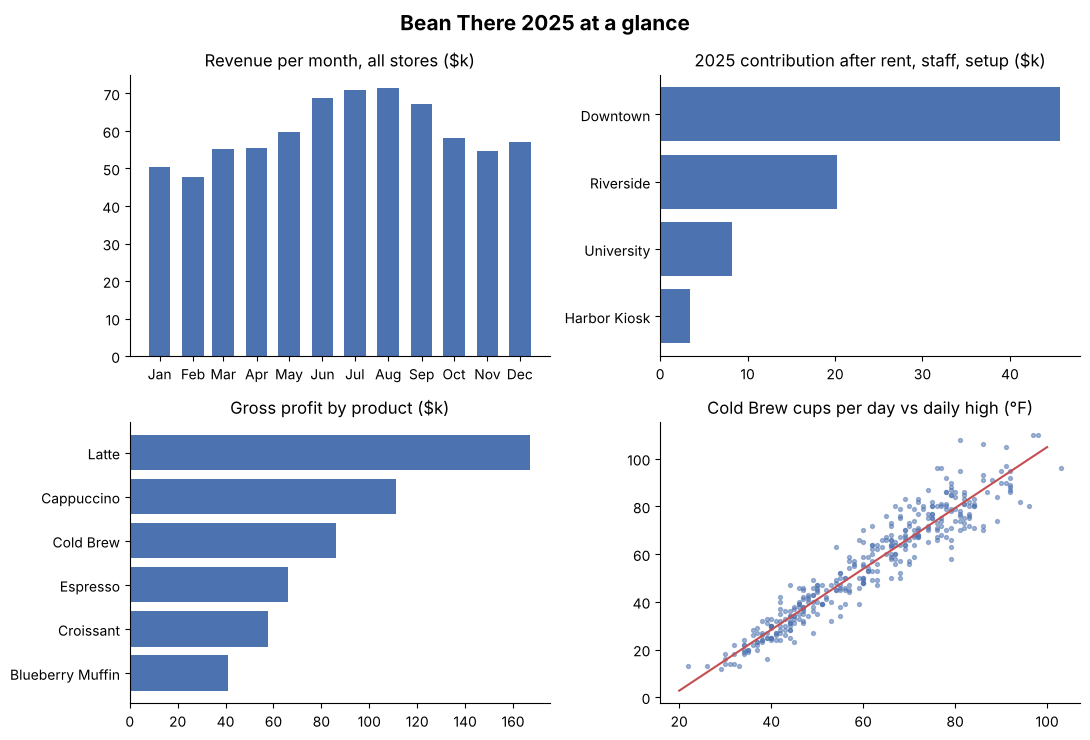

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

ax = axes[0, 0]
ax.bar(months, by_month["Total"] / 1000, width=20, color=BLUE)
ax.set_title("Revenue per month, all stores ($k)")
ax.set_xticks(months, months.strftime("%b"))

ax = axes[0, 1]
contrib_year = annual["contribution"].sort_values() / 1000
ax.barh(contrib_year.index, contrib_year.values, color=BLUE)
ax.set_title("2025 contribution after rent, staff, setup ($k)")

ax = axes[1, 0]
ax.barh(gp.index, gp.values, color=BLUE)
ax.set_title("Gross profit by product ($k)")

ax = axes[1, 1]
ax.scatter(cold["high_temp_f"], cold["cold_brew"], s=8, alpha=0.5,
           color=BLUE)
ax.plot(xs["high_temp_f"], model.predict(xs), color="#C44E52")
ax.set_title("Cold Brew cups per day vs daily high (°F)")

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Bean There 2025 at a glance", fontsize=15,
             fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "ch17-annual-dashboard.png", dpi=150)
plt.show()

### The written report

Here is the report as it appears in the final Markdown cell of the notebook. Every number in it comes from an output above.

**Bean There: 2025 annual review**

**The year in one paragraph.** Bean There sold 184,784 items for **$716,692** in revenue in 2025 and kept **$529,132 (73.8%)** after product costs. After rent, staff and the kiosk's setup, the four locations contributed **$77,532** to the business. The three cafes grew **8.7%** on 2024, faster than the year before. Growth has continued into 2026, but more slowly: the first quarter is **4.9% ahead** of the first quarter of 2025.

**Key findings**

1. **Downtown is the engine.** It earned 42% of revenue and 59% of contribution ($45,723), and it made money every month.
2. **University loses money when the students are away.** Its sales drop by about a quarter in July and August and are weak in January and February, but its costs do not change, so it lost about $3,700 in those four months. It contributed only $8,235 for the year despite taking 16% more revenue than Riverside.
3. **Riverside is small but efficient**, contributing $20,194 on the lowest costs. Its August 2024 refit did not measurably change daily sales (p = 0.81).
4. **The Harbor kiosk pilot paid for itself in one season**, leaving $3,380 after its $4,000 setup cost. It needed about $310 a day to break even: it took far more in July and August, broke even in June and fell short in September. Weekend days took about 70% more than weekdays.
5. **Lattes earn almost a third of all gross profit.** Coffee keeps 76 to 82% of its price, bakery only 60 to 63%.
6. **Cold Brew is a weather product.** Each 1°F of daily high adds about 1.3 cups a day across the cafes, and a simple forecast from the weather report was accurate to about 5 cups a day.

**Recommendations for 2026**

1. **Open the Harbor cafe (1 May) with a summer-weighted plan.** Staff fully for July, August and weekends, keep weekdays and the off-season lean, and give Sam Ortiz a daily break-even target from the first week. Review it after three months.
2. **Match University's staff hours to the academic calendar**: fewer hours in July and August, over the winter break and in early January.
3. **Order Cold Brew from the weather forecast**, using the table in Section 5 of the notebook (about 28 cups at 40°F, 54 at 60°F and 79 at 80°F across the three cafes).
4. **Do not count on refits to raise sales.** If the owner refits another store, measure it with the same before-and-after test.
5. **Protect the Latte**: any price, recipe or supplier change to it affects nearly a third of gross profit, so test changes at one store first.
6. **Watch the growth rate.** Revisit the slowdown when the first half of 2026 is complete, before deciding anything on one quarter.

**Limitations.** Contribution excludes central costs (the owner's salary, accounting, marketing), so it is not net profit. Staff costs are treated as fixed per month, which is exactly what recommendation 2 would change. The permanent Harbor cafe will have seats, higher costs and a winter season, so the kiosk pilot is a guide to its pattern, not a forecast of its profit.

### Sharing it

## 17.8 Before you press send

The reconciliation check takes one line, and it is worth running every time:

In [41]:
print(round(by_month["Total"].sum(), 2), round(sales["revenue"].sum(), 2))
print(round(annual["revenue"].sum(), 2))

716692.1 716692.1
716692.1


## 17.10 Exercises

Use `ch17_capstone.ipynb`, which already contains the clean `sales` table and everything computed in this chapter. Solutions are in Appendix D.

1. Which of the three cafes sold the most Cold Brew **per trading day** in July? *Hint:* filter to July and Cold Brew, sum quantity by store, then divide by the number of distinct dates for each store.
2. Remake the seasonality heatmap for **University only**. How does its summer pattern differ from the three-cafe version? *Hint:* change the `year_round` filter.
3. The owner wonders whether staff should suggest a pastry with every drink. Calculate the **bakery attach rate** for each store: bakery units divided by coffee units. Which store has the lowest rate?
4. What share of the units sold at the kiosk were Cold Brew, compared with the three cafes over the same four months (June to September)? What does that suggest for stocking the Harbor cafe? *Hint:* filter `sales` to months 6 to 9 and compare `Cold Brew` units with all units for each group.
5. Suppose University cuts its staff cost by 40% in January, February, July and August. How much would its 2025 contribution have changed, and what would the new annual figure be?
6. Fit the Cold Brew model **separately for each cafe** (same train and test months). Which store's Cold Brew sales are most sensitive to temperature? *Hint:* loop over `cafes`, filter, and print each model's slope.
7. Which **product** grew most between Q1 2025 and Q1 2026 (three cafes only)? *Hint:* repeat the Q1 comparison grouping by `product` instead of `store`.
8. **Think about it:** the permanent Harbor cafe is expected to cost about $9,500 a month in rent and staff. Using the kiosk's gross margin, what daily revenue will it need to break even, and which of the kiosk's four months would have cleared that bar? What else would you want to know before setting Sam's target?